In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

C:\Users\abida\anaconda3\envs\deepfake\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = "C:/Users/abida/DEEPFAKE/DeepFakeDataset"      # your dataset folder
IMAGE_SIZE = 384          # your dataset size
BATCH_SIZE = 8            # reduce if GPU memory error
EPOCHS = 15
LR = 5e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)



Using Device: cuda


In [3]:
import torch
import torch.nn as nn
import timm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model architecture
model = timm.create_model("xception", pretrained=False)

# Replace classifier
if hasattr(model, 'fc'):
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
elif hasattr(model, 'classifier'):
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)

model = model.to(DEVICE)

# Load trained weights
model.load_state_dict(torch.load("best_xception_384.pth", map_location=DEVICE))

model.eval()

print("Model loaded successfully.")

C:\Users\abida\anaconda3\envs\deepfake\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\abida\AppData\Local\Temp\ipykernel_15244\3871936356.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you do

Model loaded successfully.


In [4]:
from torchvision import transforms

IMAGE_SIZE = 384

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ✅ TEST TRANSFORM (No augmentation!)
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)


Classes: ['fake', 'real']


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report,
    accuracy_score
)

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy
all_labels = np.array(all_labels).flatten()
all_probs = np.array(all_probs).flatten()

# Binary predictions
all_preds = (all_probs > 0.5).astype(int)



<Figure size 600x600 with 0 Axes>

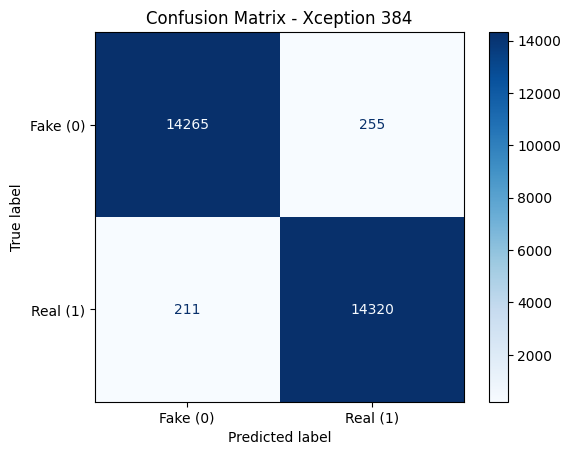

In [7]:
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake (0)", "Real (1)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Xception 384")
plt.show()

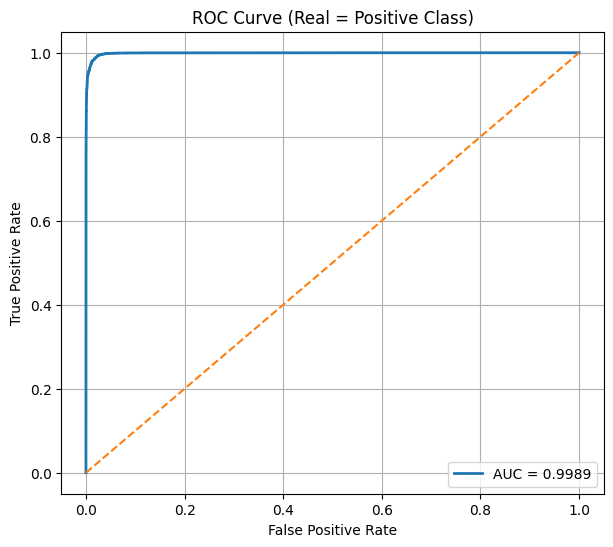

In [8]:

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Real = Positive Class)")
plt.legend()
plt.grid()
plt.show()


In [9]:


accuracy = accuracy_score(all_labels, all_preds)
sensitivity = tp / (tp + fn)   # Recall for Real
specificity = tn / (tn + fp)

print("==================================================")
print("📊 CLASSIFICATION REPORT")
print("==================================================")
print(classification_report(all_labels, all_preds, target_names=["Fake (0)", "Real (1)"]))

print("==================================================")
print(f"Accuracy      : {accuracy:.4f}")
print(f"AUC Score     : {roc_auc:.4f}")
print(f"Sensitivity   : {sensitivity:.4f}")
print(f"Specificity   : {specificity:.4f}")
print("==================================================")

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Fake (0)       0.99      0.98      0.98     14520
    Real (1)       0.98      0.99      0.98     14531

    accuracy                           0.98     29051
   macro avg       0.98      0.98      0.98     29051
weighted avg       0.98      0.98      0.98     29051

Accuracy      : 0.9840
AUC Score     : 0.9989
Sensitivity   : 0.9855
Specificity   : 0.9824


In [10]:
import torch
import torch.nn as nn
import timm
from torchvision import transforms
from PIL import Image

IMAGE_PATH = "C:/Users/abida/DEEPFAKE/DeepFakeDataset/test/real/real_101724.jpg"             # <-- Put image path here
MODEL_PATH = "best_xception_384.pth"       # <-- Your trained model

IMAGE_SIZE = 384
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
model = timm.create_model("xception", pretrained=False)

# Replace classifier
if hasattr(model, 'fc'):
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
elif hasattr(model, 'classifier'):
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully.")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])



C:\Users\abida\anaconda3\envs\deepfake\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\abida\AppData\Local\Temp\ipykernel_15244\2701600226.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you do

Model loaded successfully.


In [12]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(DEVICE)

# predict
with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability > 0.5 else 0

In [13]:
# print the results
if prediction == 1:
    print(f"Prediction: REAL ✅")
    print(f"Confidence: {probability:.4f}")
else:
    print(f"Prediction: FAKE ❌")
    print(f"Confidence: {1 - probability:.4f}")


Prediction: REAL ✅
Confidence: 1.0000


In [14]:
IMAGE_PATH = "C:/Users/abida/DEEPFAKE/DeepFakeDataset/test/fake/fake_64.jpg"             # <-- Put image path here
MODEL_PATH = "best_xception_384.pth"       # <-- Your trained model


In [15]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(DEVICE)

# predict
with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability > 0.5 else 0

In [16]:
# print the results
if prediction == 1:
    print(f"Prediction: REAL ✅")
    print(f"Confidence: {probability:.4f}")
else:
    print(f"Prediction: FAKE ❌")
    print(f"Confidence: {1 - probability:.4f}")


Prediction: FAKE ❌
Confidence: 0.9998


In [17]:
IMAGE_PATH = "C:/Users/abida/DEEPFAKE/fakeimg.jpeg"             # <-- Put image path here
MODEL_PATH = "best_xception_384.pth"       # <-- Your trained model


In [18]:
image = Image.open(IMAGE_PATH).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(DEVICE)

# predict
with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()

prediction = 1 if probability > 0.5 else 0

In [19]:
# print the results
if prediction == 1:
    print(f"Prediction: REAL ✅")
    print(f"Confidence: {probability:.4f}")
else:
    print(f"Prediction: FAKE ❌")
    print(f"Confidence: {1 - probability:.4f}")


Prediction: REAL ✅
Confidence: 0.9921


In [26]:
# ==========================================
# 🔥 JUPYTER IMAGE UPLOAD + PREDICT
# ==========================================

import torch
import torch.nn as nn
import timm
from torchvision import transforms
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import io

# ===============================
# CONFIG
# ===============================
MODEL_PATH = "best_xception_384.pth"
IMAGE_SIZE = 384
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# LOAD MODEL
# ===============================
model = timm.create_model("xception", pretrained=False)

if hasattr(model, 'fc'):
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
elif hasattr(model, 'classifier'):
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

# ===============================
# TRANSFORM
# ===============================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ===============================
# UPLOAD WIDGET
# ===============================
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

# ===============================
# PREDICTION FUNCTION
# ===============================
def on_upload_change(change):
    if uploader.value:
        for filename in uploader.value:
            content = uploader.value[filename]['content']
            image = Image.open(io.BytesIO(content)).convert("RGB")
            
            display(image)

            image_tensor = transform(image).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                output = model(image_tensor)
                probability = torch.sigmoid(output).item()

            prediction = 1 if probability > 0.5 else 0

            print("\n=================================")
            if prediction == 1:
                print(f"Prediction: REAL ✅")
                print(f"Confidence: {probability:.4f}")
            else:
                print(f"Prediction: FAKE ❌")
                print(f"Confidence: {1 - probability:.4f}")
            print("=================================")

uploader.observe(on_upload_change, names='value')

C:\Users\abida\AppData\Local\Temp\ipykernel_15244\2213256884.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=D

Model loaded successfully!


FileUpload(value=(), accept='image/*', description='Upload')